<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_2_%D0%9C%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%BD%D0%B5_%D1%84%D0%BE%D1%80%D0%BC%D1%83%D0%BB%D1%8E%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BB%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
#1 Завдання
#1.1 Функція сигмоїди
def sigmoida(z):
  result = (1 / (1 + np.exp(-z)))
  plt.plot(z, result)
  plt.grid(True)
  plt.title("Сигмоїда")
  return result

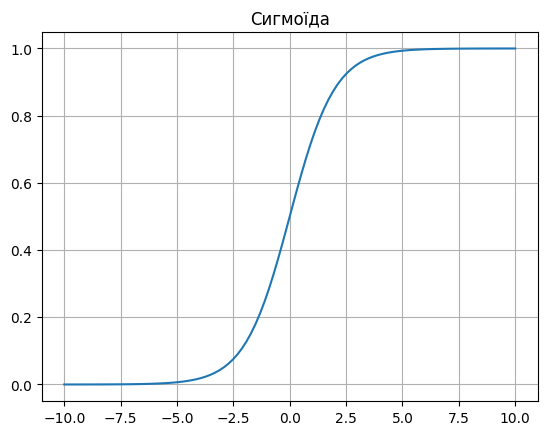

In [33]:
test_z = np.linspace(-10, 10, 100)
sigmoida(test_z)

array([0.11920292, 0.26894142, 0.5       , 0.73105858, 0.88079708])

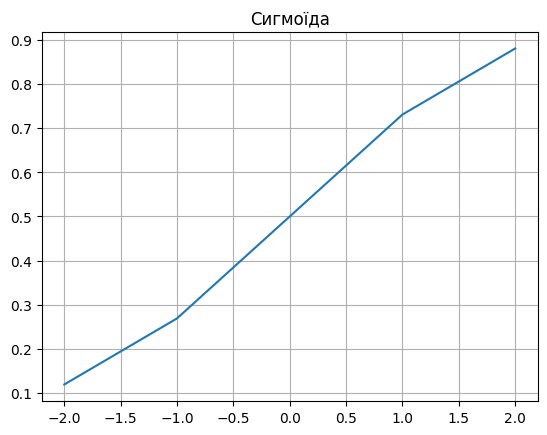

In [36]:
#1.2 Обчисліть для визначеного z

z = [-2, -1, 0, 1, 2]
sigmoida(np.array(z))



#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


In [5]:
#2.1 функція гіпотези для логістичної регресії

def hypothesis(theta, X):
  hypothesis = 1 / (1 + np.exp(-(np.dot(X, theta))))
  return hypothesis

In [6]:
#2.2 обчислення функції гіпотез для заданих значень

theta_task = np. array([0.5, -0.5])
X_task = np.array ([ [1, 2],
               [1, -1],
                [1, 0],
                [1, 1]])

In [7]:
print(f'Обчислення функції гіпотез:\n\n {hypothesis(theta_task, X_task)}')

Обчислення функції гіпотез:

 [0.37754067 0.73105858 0.62245933 0.5       ]


#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

In [19]:
#3.1
def compute_gradient(theta, X, y):
  '''Функція обчислює градієнти функції втрат для логістичної регресії.'''
  m = X.shape[0]
  gradient = (1 / m) * (np.dot(X.T, (hypothesis(theta, X) - y)))
  return gradient

In [9]:
y_task = np.array([1, 0, 1, 0])

In [20]:
#3.2 обчислення градієнтів для заданих даних:

print(f'Ваги для параметрів theta:\n\n{compute_gradient(theta_task, X_task, y_task)}')

Ваги для параметрів theta:

[ 0.05776464 -0.36899431]



#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


In [21]:
#4.1
def full_batch_gradient_descent(X, y, lr, epochs):
  '''Функція реалізує алгоритм Full batch градієнтного спуску для логістичної регресії.'''
  tetha = np. zeros(X.shape[1]) # Початкові параметри
  for _ in range(epochs):
    tetha = tetha - lr * compute_gradient(tetha, X, y)
  return tetha

In [22]:
#4.2 обчислення параметрів моделі на заданих даних:

received_weight = full_batch_gradient_descent(X_task, y_task, lr=0.1, epochs = 100)
print(f'Отримані ваги\n theta_0 = {received_weight[0]}, theta_1 = {received_weight[1]}]')

Отримані ваги
 theta_0 = -0.2893693041626857, theta_1 = 0.7765512544925172]


#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

In [23]:
#5.1
def predict_proba(theta, X):
  '''Функція обчислення ймовірностей належності поточного прикладу з даних до класу  𝑦=1  на основі значень 𝜎(𝜃𝑇𝑥) .'''
  probability = hypothesis(theta, X)
  return probability

In [14]:
predicted_probabity = predict_proba(received_weight, X_task)

for i in range (len(predicted_probabity)):
  print(f'Ймовірність для {i}-го рядка:{predicted_probabity[i]:.2f}')


Ймовірність для 0-го рядка:0.78
Ймовірність для 1-го рядка:0.26
Ймовірність для 2-го рядка:0.43
Ймовірність для 3-го рядка:0.62


In [24]:
#5.2
def predict(theta, X, threshold = 0.5):
  '''обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5.'''
  probability = predict_proba(theta, X)
  prediction = np.array([])
  for i in range(len(probability)):
    if probability[i] < threshold:
      prediction = np.append(prediction, 0)
    else:
      prediction = np.append(prediction, 1)

  return prediction


In [27]:
#5.4
prob_value = predict(received_weight, X_task, 0.5)



In [17]:
#5.3
def accuracy(y_true, y_pred):
  right_pred = 0
  for i in range(len(y_true)):
    if y_true[i] == y_pred[i]:
      right_pred += 1
  result = right_pred/len(y_true)
  return result



In [31]:
for i in range(len(prob_value)):
  print(f'Передбачена ймовірність для {i}-го рядка:{predicted_probabity[i]:.2f}\n')
  if prob_value[i] == 0:
    print(f'Модель передбачає, що об"єкт відноситься до класу 0\n')
  else:
    print(f'Модель передбачає, що об"єкт відноситься до класу 1\n')
  print(f'Згідно реальних даних, об"єкт відноситься до класу {y_task[i]}\n\n')

print(f'Точність моделі:\n {accuracy(y_task, prob_value)}')

Передбачена ймовірність для 0-го рядка:0.78

Модель передбачає, що об"єкт відноситься до класу 1

Згідно реальних даних, об"єкт відноситься до класу 1


Передбачена ймовірність для 1-го рядка:0.26

Модель передбачає, що об"єкт відноситься до класу 0

Згідно реальних даних, об"єкт відноситься до класу 0


Передбачена ймовірність для 2-го рядка:0.43

Модель передбачає, що об"єкт відноситься до класу 0

Згідно реальних даних, об"єкт відноситься до класу 1


Передбачена ймовірність для 3-го рядка:0.62

Модель передбачає, що об"єкт відноситься до класу 1

Згідно реальних даних, об"єкт відноситься до класу 0


Точність моделі:
 0.5
